In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

In [15]:
DATA_PATH = Path(
    "llm_judge_output.jsonl"
)

rows = []
with DATA_PATH.open() as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
df.head()

,exam_id,page_id,question_id,question_type,question_text,answer_type,student_answer,canonical_answer,llm_score,llm_comment,final_score,max_score
0,exam_1,2,1,text,What is the pKa of a sp hybridized carbon atom...,single_choice,The pKa of a sp hybridized carbon atom is 50. ...,A,0.00,The student provided an incorrect answer (D in...,0.0,1.0
1,exam_1,2,2,text,A) choose the letter of the molecule with the ...,multiple_choice,The molecule with the lowest barrier to rotati...,A;D,0.25,The student correctly identified cyclohexane a...,0.5,2.0
2,exam_1,2,3,text,Rank the following substituents in order of pr...,ordering,1. -CH=CH2\n2. -CN\n3. -CH2NH2\n4. -CH2Br\n\n1...,4;2;3;1,0.20,The student's ranking is incorrect; the correc...,0.4,2.0
3,exam_1,2,4,text,If a chiral molecule has an absolute configura...,single_choice,.\n\nA) clockwise (dextrorotary)\n\nAnswer: A\...,D,0.00,The student selected an incorrect answer (A) i...,0.0,1.0
4,exam_1,3,5,multimodal,A) Enter the pKa value for each acid in the bo...,text,A) pKa values:\n\n1. Phenol: 10.0\n2. Water: 1...,box_1=8-11; box_2=15.7; box_3=10-11; box_4=4-5,0.50,The pKa values for phenol and water are incorr...,3.0,6.0


In [18]:
required_cols = ["max_score", "llm_score"]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df[required_cols].head()

,max_score,llm_score
0,1.0,0.00
1,2.0,0.25
2,2.0,0.20
3,1.0,0.00
4,6.0,0.50


In [24]:
df["earned_score"] = df["max_score"] * df["llm_score"]
total_max_score = df["max_score"].sum()
print(f"Total max score: {total_max_score}")
total_earned_score = df["earned_score"].sum()
print(f"Total earned score: {total_earned_score}")
score_percent = 100 * total_earned_score / total_max_score
print(f"Score percent: {score_percent:.2f}%")

Total max score: 535.0
Total earned score: 88.7
Score percent: 16.58%


In [25]:
summary = pd.DataFrame({
    "metric": [
        "Total max score",
        "Total earned score",
        "Score percentage"
    ],
    "value": [
        total_max_score,
        total_earned_score,
        f"{score_percent:.2f}%"
    ]
})

summary

,metric,value
0,Total max score,535.0
1,Total earned score,88.7
2,Score percentage,16.58%


In [16]:
# Защита от деления на 0
df = df[df["max_score"] > 0].copy()

# Нормализованный скор (на всякий случай)
df["normalized_score"] = df["final_score"] / df["max_score"]

df.describe()

,page_id,llm_score,final_score,max_score,normalized_score
count,75.00000,75.000000,75.000000,75.000000,75.000000
mean,4.92000,0.172000,1.182667,7.133333,0.172000
std,2.49735,0.216427,1.712780,5.107846,0.216427
min,2.00000,0.000000,0.000000,1.000000,0.000000
25%,3.00000,0.000000,0.000000,4.000000,0.000000
50%,5.00000,0.000000,0.000000,6.000000,0.000000
75%,6.00000,0.300000,2.200000,10.000000,0.300000
max,11.00000,0.800000,9.000000,30.000000,0.800000


In [4]:
average_score_micro = df["final_score"].sum() / df["max_score"].sum()
average_score_micro

0.1657943925233645

In [5]:
exam_scores = (
    df.groupby("exam_id")
      .agg(
          exam_final_score=("final_score", "sum"),
          exam_max_score=("max_score", "sum"),
    )
)

exam_scores["exam_score"] = (
    exam_scores["exam_final_score"] /
    exam_scores["exam_max_score"]
)

average_score_macro_exam = exam_scores["exam_score"].mean()
average_score_macro_exam

0.16734146149508713

In [6]:
by_question_type = (
    df.groupby("question_type")
      .agg(
          final_score=("final_score", "sum"),
          max_score=("max_score", "sum"),
          n_questions=("question_id", "count"),
    )
)

by_question_type["average_score"] = (
    by_question_type["final_score"] /
    by_question_type["max_score"]
)

by_question_type.sort_values("average_score", ascending=False)

,final_score,max_score,n_questions,average_score
question_type,,,,
multimodal,87.8,506.0,66,0.173518
text,0.9,29.0,9,0.031034


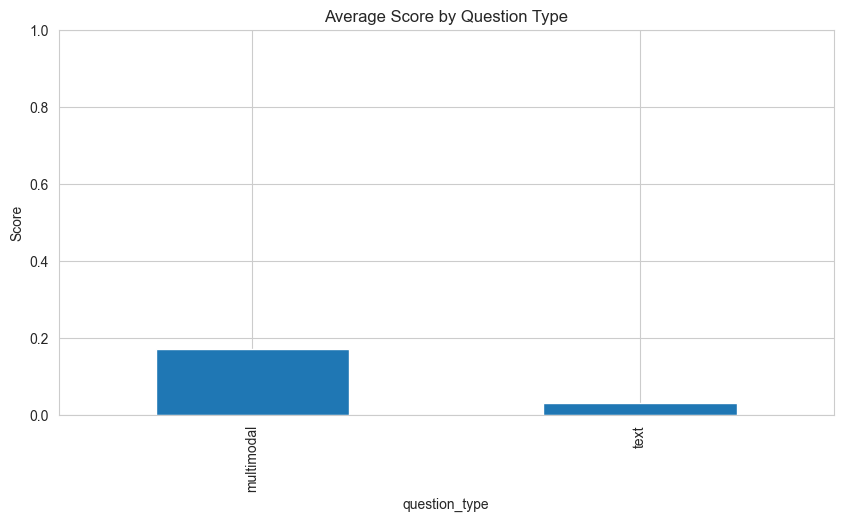

In [7]:
by_question_type["average_score"].plot(
    kind="bar",
    ylim=(0, 1),
    title="Average Score by Question Type",
)
plt.ylabel("Score")
plt.show()

In [8]:
by_answer_type = (
    df.groupby("answer_type")
      .agg(
          final_score=("final_score", "sum"),
          max_score=("max_score", "sum"),
          n_questions=("question_id", "count"),
    )
)

by_answer_type["average_score"] = (
    by_answer_type["final_score"] /
    by_answer_type["max_score"]
)

by_answer_type.sort_values("average_score", ascending=False)

,final_score,max_score,n_questions,average_score
answer_type,,,,
reaction_description,9.0,18.0,1,0.500000
full_synthesis,11.8,35.0,4,0.337143
text,61.6,323.0,42,0.190712
multiple_choice,1.9,25.0,5,0.076000
structure,4.0,100.0,12,0.040000
ordering,0.4,24.0,5,0.016667
numeric,0.0,1.0,1,0.000000
single_choice,0.0,9.0,5,0.000000


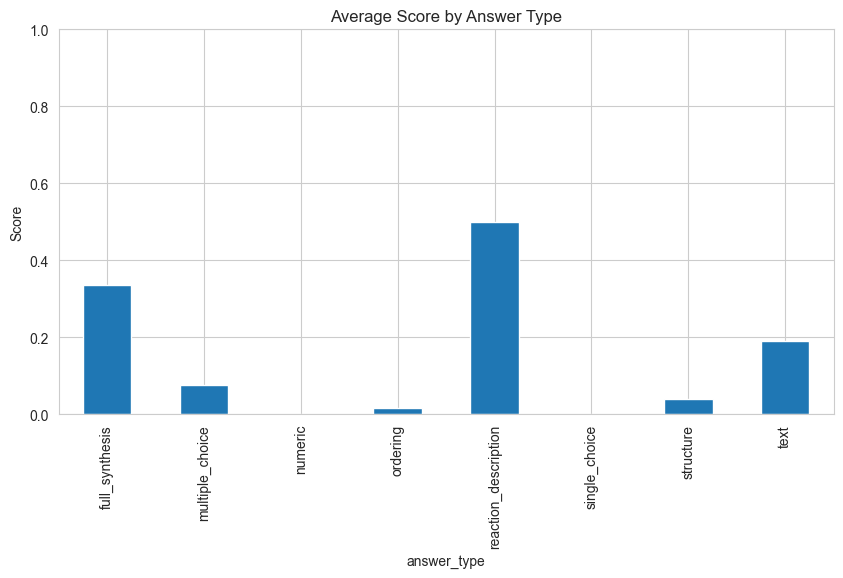

In [9]:
by_answer_type["average_score"].plot(
    kind="bar",
    ylim=(0, 1),
    title="Average Score by Answer Type",
)
plt.ylabel("Score")
plt.show()

In [10]:
pivot = pd.pivot_table(
    df,
    values="normalized_score",
    index="question_type",
    columns="answer_type",
    aggfunc="mean"
)

pivot

answer_type,full_synthesis,multiple_choice,numeric,ordering,reaction_description,single_choice,structure,text
question_type,,,,,,,,
multimodal,0.425,0.05,0.0,0.0,0.5,0.0,0.05,0.23625
text,NaN,0.25,NaN,0.1,NaN,0.0,NaN,0.00000


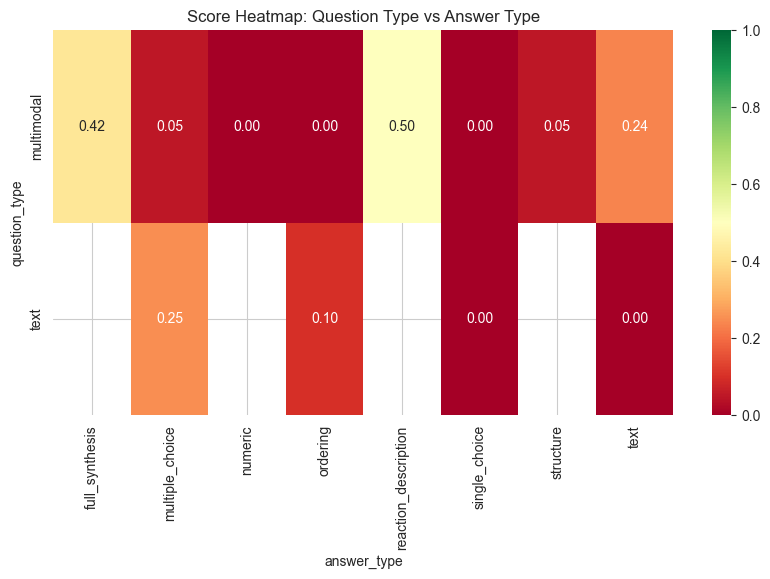

In [11]:
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1
)
plt.title("Score Heatmap: Question Type vs Answer Type")
plt.show()

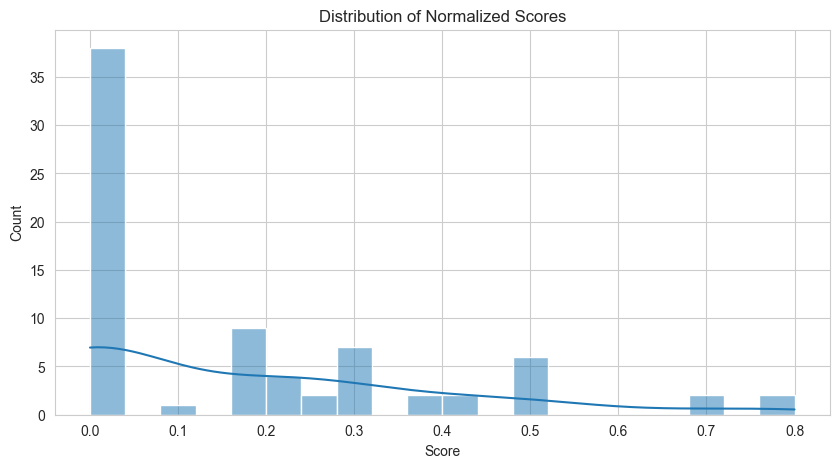

In [12]:
sns.histplot(
    df["normalized_score"],
    bins=20,
    kde=True
)
plt.title("Distribution of Normalized Scores")
plt.xlabel("Score")
plt.show()